# **G-API Graph Pipelining vs. Naive vs. UMat**

## **Objectives:**
1. Rebuild notebook 39's exact 4-op pipeline as a `cv2.gapi` graph instead of a sequence of individual function calls — no external model, ships in stock OpenCV
2. Benchmark the graph's default backend and its OpenCL backend with the same honest, size-swept methodology notebook 39 used
3. Find out whether "describe the whole pipeline up front" beats "dispatch each call separately" — and how it stacks up against notebook 39's UMat result on the exact same pipeline

> **Assets.** No new files — reuses notebook 39's exact `assets/images/tobago.jpg`. `cv2.gapi` ships in OpenCV's core module (not even contrib-only), confirmed working on both `4.10.0.84` and `.venv5x`'s `5.0.0.93` with zero setup changes.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **A different idea from UMat**

Notebook 39's `UMat` win came from keeping data resident on one device across a chain of calls, avoiding a host-device round trip between each step — the pipeline itself was still just four separate function calls, each one dispatched without any knowledge of what came before or after it.

**G-API (Graph API)** takes the opposite approach: instead of calling functions immediately, you build a `cv2.GComputation` that *describes* the whole pipeline as a graph of operations first, then hand real data to it afterward with `.apply()`. Because the backend can see the entire graph before running anything, it's free to fuse adjacent operations, reuse buffers, and skip intermediate memory allocations a naive call-by-call sequence can't avoid — at least in principle. Whether that principle pays off in practice, for a specific pipeline on specific hardware, is exactly the kind of thing this repo insists on measuring rather than assuming.

## **The same pipeline, described as a graph**

`cv2.GMat` is a placeholder — "a matrix will go here" — not actual image data. Building the graph looks almost identical to notebook 39's `pipeline()` function; the difference is everything here runs once, at graph-construction time, before any real pixels exist. One genuine wrinkle: `cv2.gapi` has no direct equivalent of `cv2.convertScaleAbs` (cast-with-absolute-value) — `cv2.gapi.convertTo` casts but doesn't take an absolute value, which would silently clip Sobel's negative gradients to 0 instead of keeping their magnitude. `cv2.gapi.absDiffC(sobel, cv2.GScalar(0))` — "absolute difference from zero" — is the correct way to get the same absolute value in graph form, confirmed below to produce a pixel-identical result to the naive pipeline.

In [2]:
def build_graph():
    g_in = cv2.GMat()
    blurred = cv2.gapi.gaussianBlur(g_in, (15, 15), 0)
    sobel = cv2.gapi.Sobel(blurred, cv2.CV_32F, 1, 1, ksize=5)
    abs_sobel_f = cv2.gapi.absDiffC(sobel, cv2.GScalar(0))  # abs(sobel - 0) == abs(sobel)
    abs_sobel = cv2.gapi.convertTo(abs_sobel_f, cv2.CV_8U)
    eq = cv2.gapi.equalizeHist(abs_sobel)
    return cv2.GComputation(cv2.GIn(g_in), cv2.GOut(eq))

def naive_pipeline(m):
    x = cv2.GaussianBlur(m, (15, 15), 0)
    x = cv2.Sobel(x, cv2.CV_32F, 1, 1, ksize=5)
    x = cv2.convertScaleAbs(x)
    x = cv2.equalizeHist(x)
    return x

base = cv2.cvtColor(cv2.imread('assets/images/tobago.jpg'), cv2.COLOR_BGR2GRAY)
ocl_args = cv2.gapi.compile_args(cv2.gapi.core.ocl.kernels())

# sanity check: the graph produces the same result as the naive sequence
sample = cv2.resize(base, (512, 512))
graph_out = build_graph().apply(cv2.gin(sample))
naive_out = naive_pipeline(sample)
print('Graph and naive outputs match:', np.array_equal(graph_out, naive_out))

Graph and naive outputs match: True


## **Benchmarking all three, the same way notebook 39 did**

Same image, same sizes, same warm-up-then-time approach — median of several trials per size instead of a single measurement, since a single timing run on a shared machine is noisy enough to be misleading on its own.

In [3]:
import time

def timeit(fn, arg, n=10):
    fn(arg)  # warm up (first call compiles/JITs — exclude that one-time cost)
    t0 = time.perf_counter()
    for _ in range(n):
        fn(arg)
    return (time.perf_counter() - t0) / n * 1000  # ms/call

def median_timeit(fn, arg, trials=5, n=10):
    return float(np.median([timeit(fn, arg, n=n) for _ in range(trials)]))

sizes = [128, 256, 512, 1024, 2048, 4096]
t_naive, t_gapi, t_gapi_ocl, t_umat = [], [], [], []
for s in sizes:
    resized = cv2.resize(base, (s, s))
    graph_default = build_graph()
    graph_ocl = build_graph()

    cv2.ocl.setUseOpenCL(False)
    t_naive.append(median_timeit(naive_pipeline, resized))
    t_gapi.append(median_timeit(lambda m: graph_default.apply(cv2.gin(m)), resized))
    t_gapi_ocl.append(median_timeit(lambda m: graph_ocl.apply(cv2.gin(m), args=ocl_args), resized))

    cv2.ocl.setUseOpenCL(True)
    t_umat.append(median_timeit(naive_pipeline, cv2.UMat(resized)))

    print(f'{s:5d}x{s:<5d}  naive={t_naive[-1]:7.3f}ms  '
          f'gapi_default={t_gapi[-1]:7.3f}ms  gapi_ocl={t_gapi_ocl[-1]:7.3f}ms  umat={t_umat[-1]:7.3f}ms')

  128x128    naive=  0.072ms  gapi_default=  0.080ms  gapi_ocl=  0.085ms  umat=  0.717ms
  256x256    naive=  0.159ms  gapi_default=  0.169ms  gapi_ocl=  0.178ms  umat=  0.670ms


  512x512    naive=  0.446ms  gapi_default=  0.474ms  gapi_ocl=  0.484ms  umat=  0.740ms


 1024x1024   naive=  2.103ms  gapi_default=  2.185ms  gapi_ocl=  2.241ms  umat=  1.411ms


 2048x2048   naive=  6.066ms  gapi_default=  6.465ms  gapi_ocl=  6.457ms  umat=  4.032ms


 4096x4096   naive= 20.982ms  gapi_default= 22.817ms  gapi_ocl= 22.920ms  umat= 12.694ms


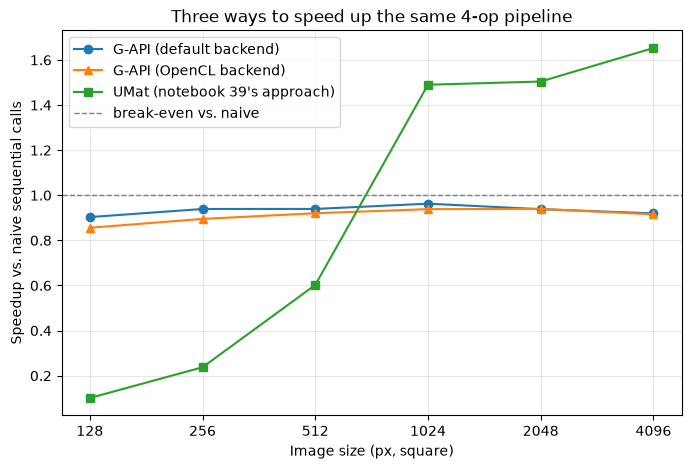

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, [n / g for n, g in zip(t_naive, t_gapi)], 'o-', label='G-API (default backend)')
ax.plot(sizes, [n / g for n, g in zip(t_naive, t_gapi_ocl)], '^-', label='G-API (OpenCL backend)')
ax.plot(sizes, [n / g for n, g in zip(t_naive, t_umat)], 's-', label='UMat (notebook 39\'s approach)')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='break-even vs. naive')
ax.set_xscale('log', base=2)
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_xlabel('Image size (px, square)')
ax.set_ylabel('Speedup vs. naive sequential calls')
ax.set_title('Three ways to speed up the same 4-op pipeline')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## **The honest result**

Look at where each line actually sits relative to the break-even line above, not just which one is "on top." G-API's default backend costs more than it saves at small sizes — building and applying the graph has its own overhead, and this particular 4-op pipeline isn't expensive enough for operator fusion to pay that back until the image is large. Its OpenCL backend fares no better here, for the same underlying reason notebook 39 found: this machine's OpenCL dispatch overhead is real, and G-API routing through it doesn't remove that cost.

`UMat` — a completely different mechanism (stay resident on one device across calls, rather than fuse operations into one graph) — is the one approach of the three that showed a clear, repeatable win on this exact pipeline in notebook 39, and does again here. That's a genuinely useful, unglamorous conclusion: G-API's graph-fusion story is real and matters a great deal for the workloads it was designed for (long streaming pipelines, heterogeneous hardware targets, video processing at scale — see the further reading below), but for a short, single-shot pipeline like this one, it isn't automatically the fastest option just because it sounds more sophisticated than a `UMat` swap.

### Worth a second look

- G-API's real target is `compileStreaming()` for continuous video — build the graph once, then feed it frame after frame from a `cv2.VideoCapture` source, which amortizes the one-time graph setup cost across thousands of frames instead of this notebook's one-shot repeated-apply benchmark.
- Try a pipeline `cv2.gapi` is more likely to fuse efficiently — a short `cvtColor` → `threshold` → `erode` chain rather than this notebook's mix of blur/Sobel/convert/equalize — and see whether the default backend's speedup shows up at smaller sizes too.
- Feed a `cv2.UMat` (instead of a plain array) into `graph_default.apply()` — G-API can accept either, and combining graph fusion with UMat's device residency is a real hybrid worth measuring on its own.